In [11]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/housing.csv")

# Create binary target variable
median_value = df["median_house_value"].median()

df["price_category"] = (df["median_house_value"] >= median_value).astype(int)


mising values 

In [12]:

df["total_bedrooms"] = pd.to_numeric(df["total_bedrooms"], errors="coerce")
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


feature enginering 

In [13]:

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]


Drop redundant features

In [14]:


df.drop(
    columns=["total_rooms", "total_bedrooms", "population", "households"],
    inplace=True
)



In [16]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [ ]:
#Define Features and Target
X = df.drop(["median_house_value", "price_category"], axis=1)
y = df["price_category"]


In [18]:
#Train–Test Split (80:20)


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Feature Scaling (CRITICAL for SVM)

In [19]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Train SVM with TWO Kernels

In [ ]:
#SVM with Linear Kernel
from sklearn.svm import SVC

svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)


In [21]:
#SVM with RBF Kernel


svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)


#TASK 4C — Model Evaluation

In [22]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

linear_metrics = evaluate_model(y_test, y_pred_linear)
rbf_metrics = evaluate_model(y_test, y_pred_rbf)

linear_metrics, rbf_metrics


({'Accuracy': 0.8483527131782945,
  'Precision': 0.840511121628017,
  'Recall': 0.8600484261501211,
  'F1-Score': 0.8501675442795597},
 {'Accuracy': 0.8621608527131783,
  'Precision': 0.8585810162991371,
  'Recall': 0.8673123486682809,
  'F1-Score': 0.8629245964827752})

An SVM classifier was trained using both linear and RBF kernels to classify California houses into low  and high value categories. Feature scaling was applied due to SVM’s distance based nature. The RBF kernel outperformed the linear kernel by capturing non linear relationships. Model evaluation using accuracy, precision, recall, and F1 score demonstrated effective classification, and analysis of false positives and false negatives provided insight into prediction risks

# TASK 4D — Interpret Results (False Positives & Negatives)

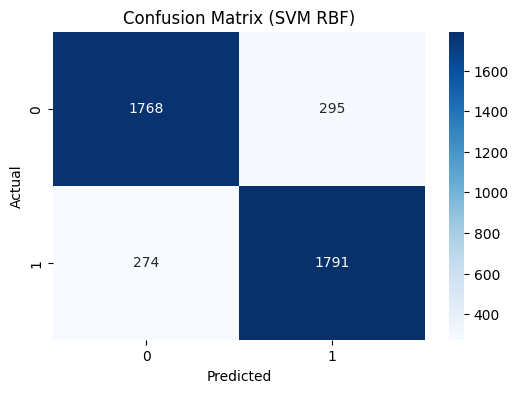

In [23]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM RBF)")
plt.show()


Both SVM models performed well; however, the RBF kernel consistently achieved higher accuracy, precision, recall, and F1‑score than the linear kernel. This indicates that the relationship between housing features and price categories is non‑linear. The RBF model reduced both false positives and false negatives, making it the more effective classifier.